## 探索的データ分析ノートブック(デッキ)

In [22]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
import os
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb
import torch
import sys
import torch
import random
import math

plt.rcParams['font.family'] = 'Hiragino Sans'

### データの読み込み（デッキデータ）

In [6]:

csv_path = os.path.join('../data/ranking_train.csv')
json_path = os.path.join('../data/cards.json')

df = pd.read_csv(csv_path)

with open(json_path, 'r', encoding='utf-8') as f:
    cards_data = json.load(f)
    
# ID -> 名前 のマッピング辞書
id_to_name = {}
for card_id_str, name_info in cards_data.items():
    if isinstance(name_info, dict) and "name" in name_info:
        id_to_name[int(card_id_str)] = name_info["name"]
    else:
        id_to_name[int(card_id_str)] = str(name_info)

# card1 ~ card8 の列だけを抽出してリスト化
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'card7', 'card8']
decks = df[card_cols].values.tolist()

# IDを名前に変換
decks_names = []
for deck in decks:
    decks_names.append([id_to_name.get(card_id, f"Unknown({card_id})") for card_id in deck])

print(f" {len(decks_names)} 件のデッキデータを読み込みました")
print(pd.DataFrame(decks_names).head(5))

 619647 件のデッキデータを読み込みました
            0               1               2               3  \
0   Hog Rider          Guards     Executioner  Electro Spirit   
1   Skeletons  Giant Skeleton     Dart Goblin            Bats   
2     Goblins          Wizard  Giant Skeleton     Dark Prince   
3  Lumberjack     Royal Ghost         Zappies     Cannon Cart   
4       Witch        Valkyrie       Berserker      Goblin Hut   

                 4               5                 6               7  
0        Berserker       Lightning  Barbarian Barrel  Giant Snowball  
1  Skeleton Barrel  Electro Spirit           The Log           Clone  
2       Battle Ram     Royal Ghost      Mother Witch           Vines  
3    Golden Knight    Mother Witch  Barbarian Barrel     Heal Spirit  
4           Poison       Graveyard  Barbarian Barrel           Vines  


### 全カード使用率の可視化

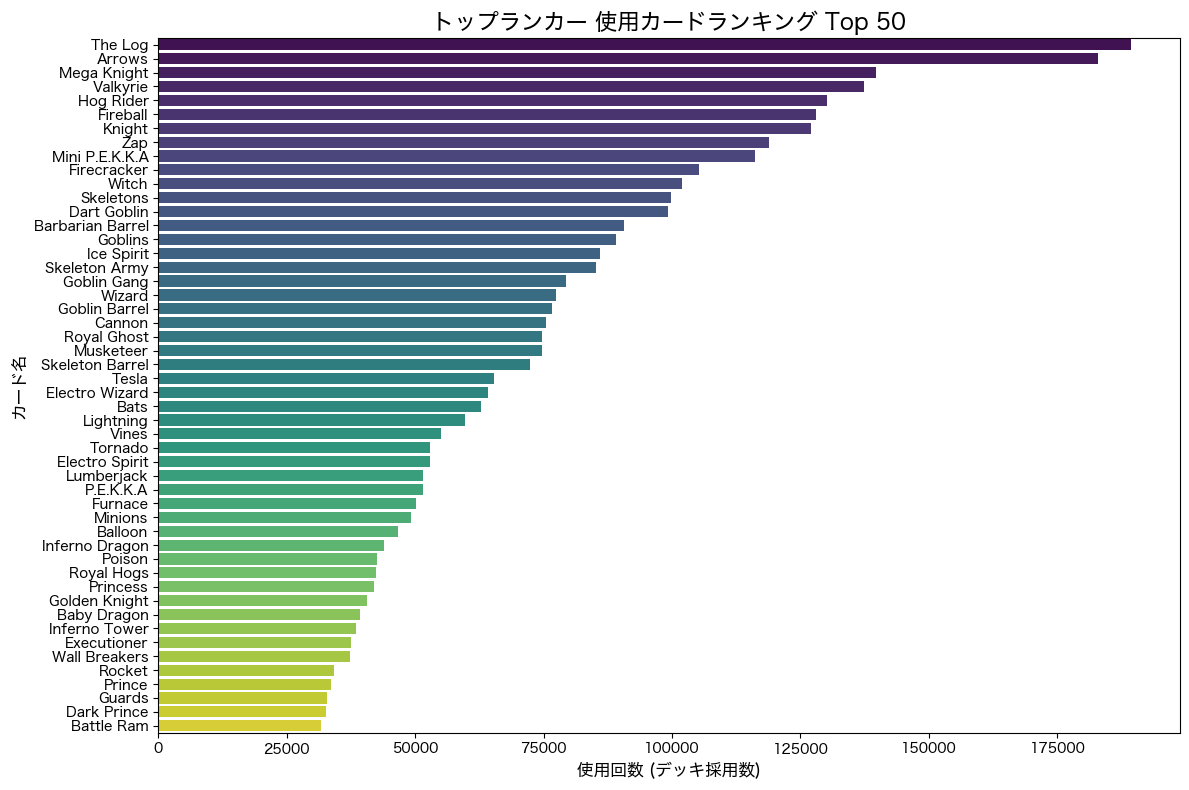

In [8]:
all_cards = [card for deck in decks_names for card in deck]
card_counts = Counter(all_cards)

top_50 = card_counts.most_common(50)
top_50_names = [x[0] for x in top_50]
top_50_counts = [x[1] for x in top_50]

plt.figure(figsize=(12, 8))


sns.barplot(
    x=top_50_counts, 
    y=top_50_names, 
    hue=top_50_names, 
    palette='viridis', 
    legend=False
)

plt.title('トップランカー 使用カードランキング Top 50', fontsize=16)
plt.xlabel('使用回数 (デッキ採用数)', fontsize=12)
plt.ylabel('カード名', fontsize=12)
plt.tight_layout()
plt.show()

### ランクインしたカードの組み合わせヒートマップ

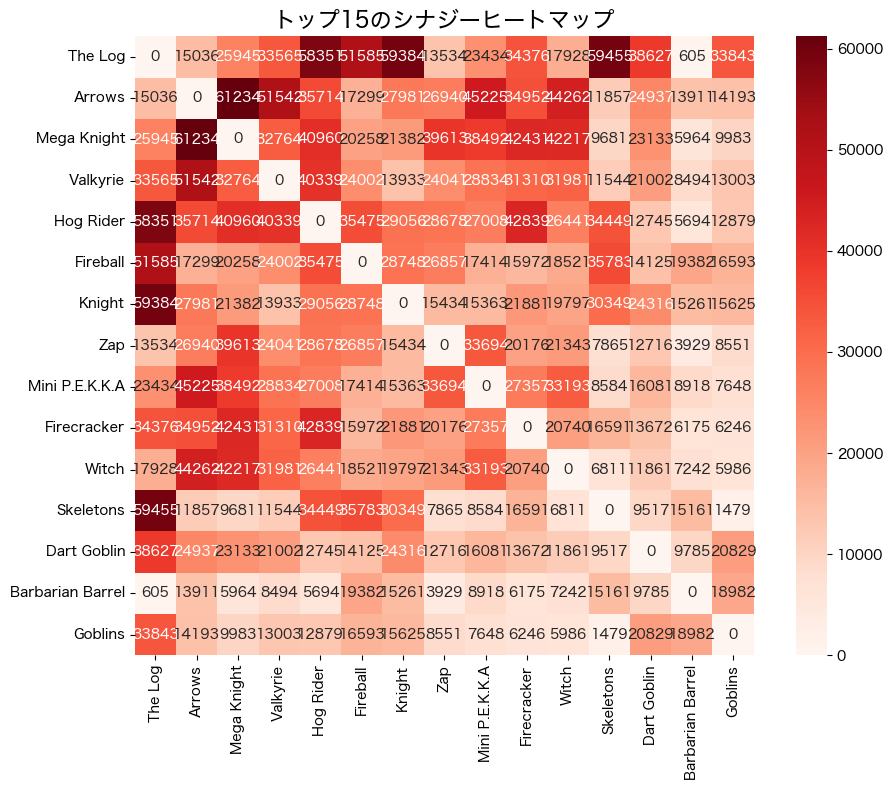

In [10]:
pair_counts = Counter()
for deck in decks_names:
    for pair in combinations(sorted(deck), 2):
        pair_counts[pair] += 1

top_15_names = [x[0] for x in card_counts.most_common(15)]
synergy_df = pd.DataFrame(0, index=top_15_names, columns=top_15_names)

for (card1, card2), count in pair_counts.items():
    if card1 in top_15_names and card2 in top_15_names:
        synergy_df.at[card1, card2] = count
        synergy_df.at[card2, card1] = count # 対称行列にする

# 対角成分（同じカード同士）は0にして色を抜く
for name in top_15_names:
    synergy_df.at[name, name] = 0

plt.figure(figsize=(10, 8))
sns.heatmap(synergy_df, annot=True, fmt='d', cmap='Reds', square=True)
plt.title('トップ15のシナジーヒートマップ', fontsize=16)
plt.tight_layout()
plt.show()

### ユニットカードの使用率の可視化

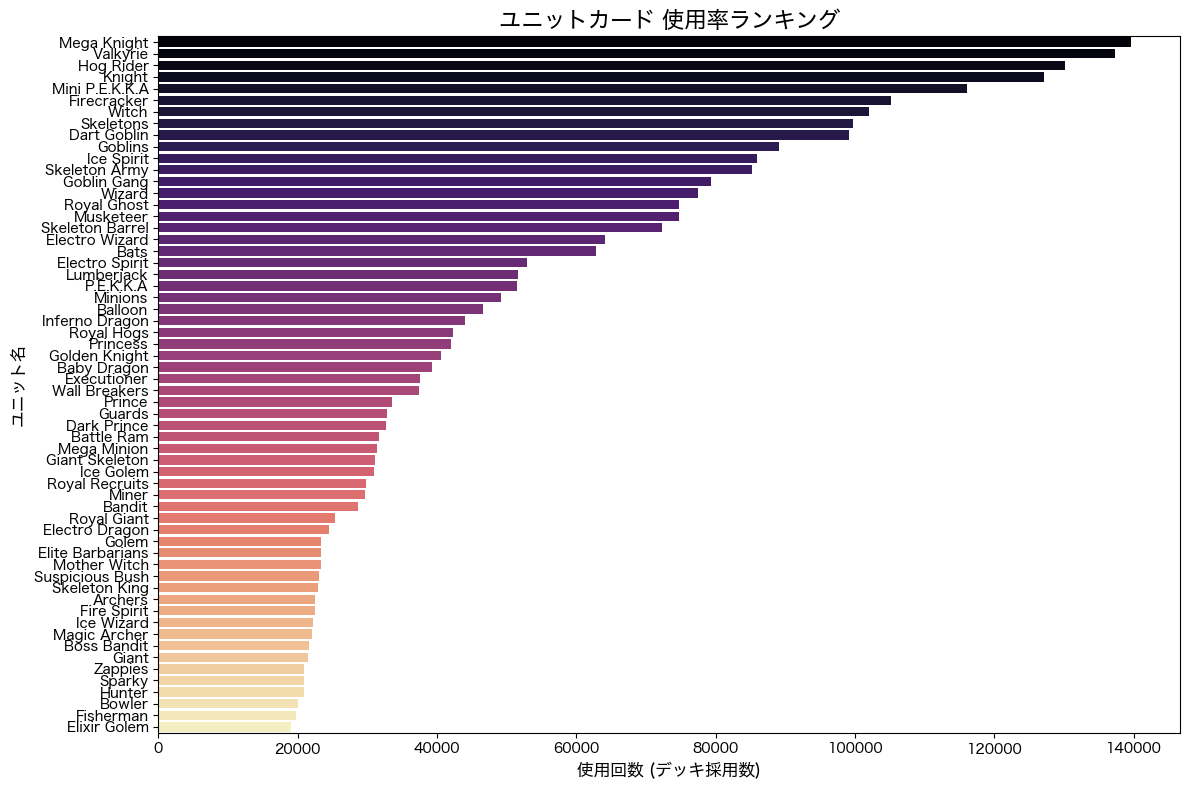

In [17]:
# ==========================================
# 1. デッキから「ユニット（IDが26000000番台）」だけを抽出
# ==========================================
unit_decks_names = []
for deck_ids in decks: # decks は [26000021, 28000011, ...] のような生IDのリスト
    unit_deck = []
    for card_id in deck_ids:
        # IDが '26' から始まるものをユニットとして判定
        if str(card_id).startswith('26'): 
            unit_deck.append(id_to_name.get(card_id, f"Unknown({card_id})"))
    unit_decks_names.append(unit_deck)

# ==========================================
# 2. ユニットの使用率ランキング
# ==========================================
all_units = [unit for deck in unit_decks_names for unit in deck]
unit_counts = Counter(all_units)

top_units = unit_counts.most_common(60) 
top_unit_names = [x[0] for x in top_units]
top_unit_counts = [x[1] for x in top_units]

plt.figure(figsize=(12, 8))
# ユニットっぽさを出すために色を 'magma' (紫〜オレンジ) に変更
sns.barplot(x=top_unit_counts, y=top_unit_names, hue=top_unit_names, palette='magma', legend=False)
plt.title('ユニットカード 使用率ランキング', fontsize=16)
plt.xlabel('使用回数 (デッキ採用数)', fontsize=12)
plt.ylabel('ユニット名', fontsize=12)
plt.tight_layout()
plt.show()


### 呪文カードの使用率の可視化

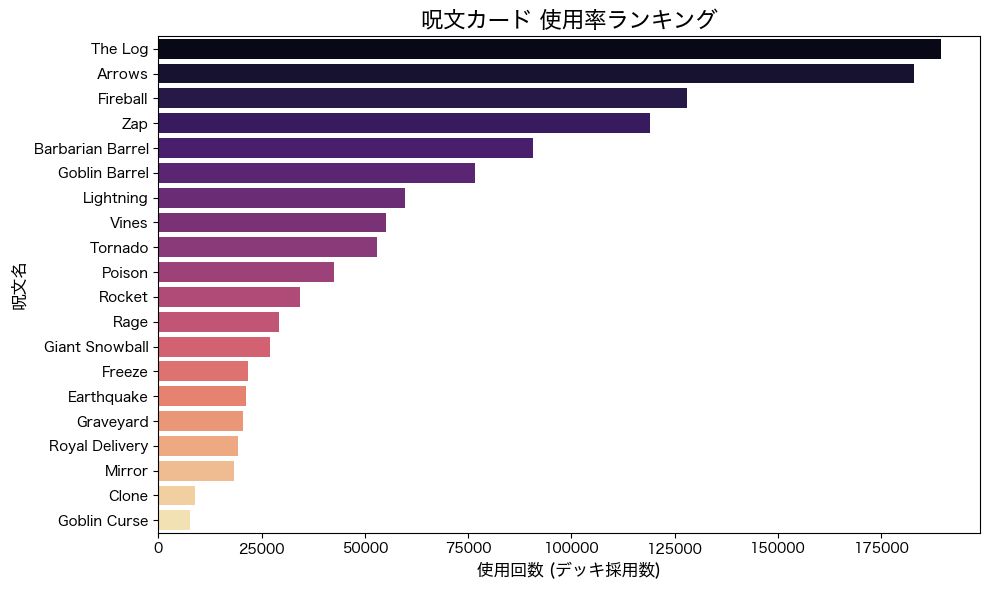

In [ ]:
# ==========================================
# 1. デッキから「呪文（IDが28000000番台）」だけを抽出
# ==========================================
spell_decks_names = []
for deck_ids in decks: # decks は [26000021, 28000011, ...] のような生IDのリスト
    spell_deck = []
    for card_id in deck_ids:
        # IDが '28' から始まるものを呪文として判定
        if str(card_id).startswith('28'): 
            spell_deck.append(id_to_name.get(card_id, f"Unknown({card_id})"))
    spell_decks_names.append(spell_deck)

# ==========================================
# 2. 呪文の使用率ランキング
# ==========================================
all_spells = [spell for deck in spell_decks_names for spell in deck]
spell_counts = Counter(all_spells)

# 呪文は全体の枚数が少ないので、トップ20
top_spells = spell_counts.most_common(20) 
top_spell_names = [x[0] for x in top_spells]
top_spell_counts = [x[1] for x in top_spells]

plt.figure(figsize=(10, 6))
# 呪文っぽさを出すために色を 'magma' (紫〜オレンジ) に変更
sns.barplot(x=top_spell_counts, y=top_spell_names, hue=top_spell_names, palette='magma', legend=False)
plt.title('呪文カード 使用率ランキング', fontsize=16)
plt.xlabel('使用回数 (デッキ採用数)', fontsize=12)
plt.ylabel('呪文名', fontsize=12)
plt.tight_layout()
plt.show()


### 呪文の組み合わせヒートマップ

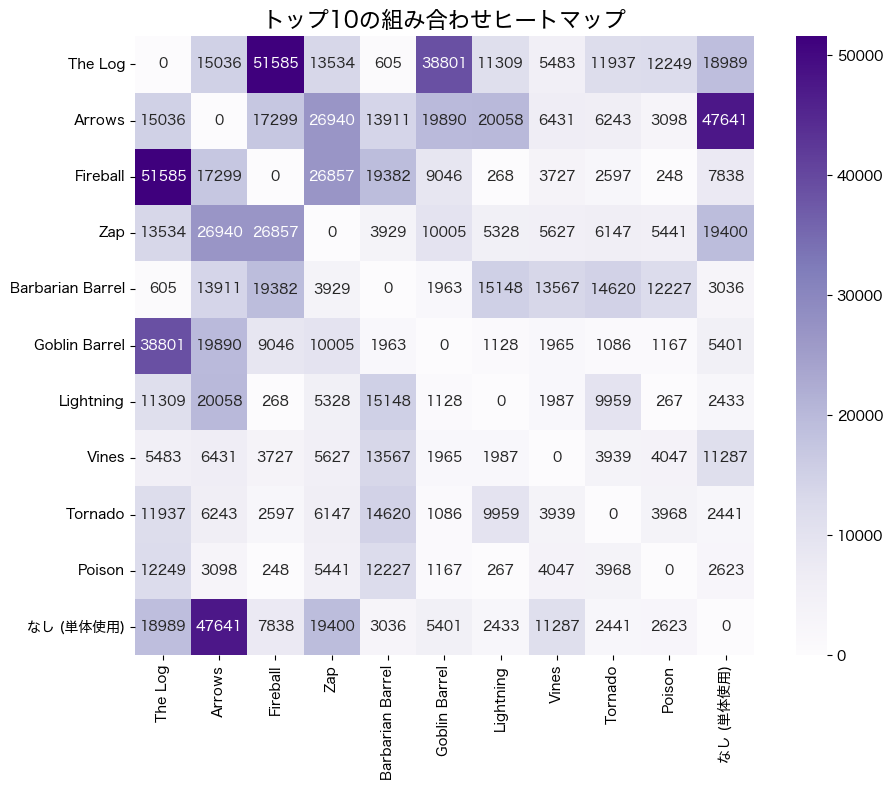

In [13]:
spell_pair_counts = Counter()
for deck in spell_decks_names:
    if len(deck) == 0:
        continue # 呪文0枚の超特異デッキはスキップ
    elif len(deck) == 1:
        # 呪文が1枚だけの場合、「なし (単体使用)」とのコンビとして集計！
        spell_pair_counts[(deck[0], 'なし (単体使用)')] += 1
    else:
        # 呪文が2枚以上の場合は通常の組み合わせ
        for pair in combinations(sorted(deck), 2):
            spell_pair_counts[pair] += 1

# トップ10の呪文に「なし (単体使用)」を加えて、ヒートマップの枠組みを作る
top_10_spells = [x[0] for x in spell_counts.most_common(10)]
heatmap_labels = top_10_spells + ['なし (単体使用)']

spell_synergy_df = pd.DataFrame(0, index=heatmap_labels, columns=heatmap_labels)

for (spell1, spell2), count in spell_pair_counts.items():
    # 抽出したラベルの中にある組み合わせだけをDataFrameに入れる
    if spell1 in heatmap_labels and spell2 in heatmap_labels:
        spell_synergy_df.at[spell1, spell2] = count
        spell_synergy_df.at[spell2, spell1] = count

# 対角成分（同じ呪文同士）は0にして色を抜く
for name in heatmap_labels:
    spell_synergy_df.at[name, name] = 0

plt.figure(figsize=(10, 8)) # 「なし」が増えた分、少しだけ図を大きくしました
sns.heatmap(spell_synergy_df, annot=True, fmt='d', cmap='Purples', square=True)
plt.title('トップ10の組み合わせヒートマップ', fontsize=16)
plt.tight_layout()
plt.show()

### 建物カード使用率の可視化

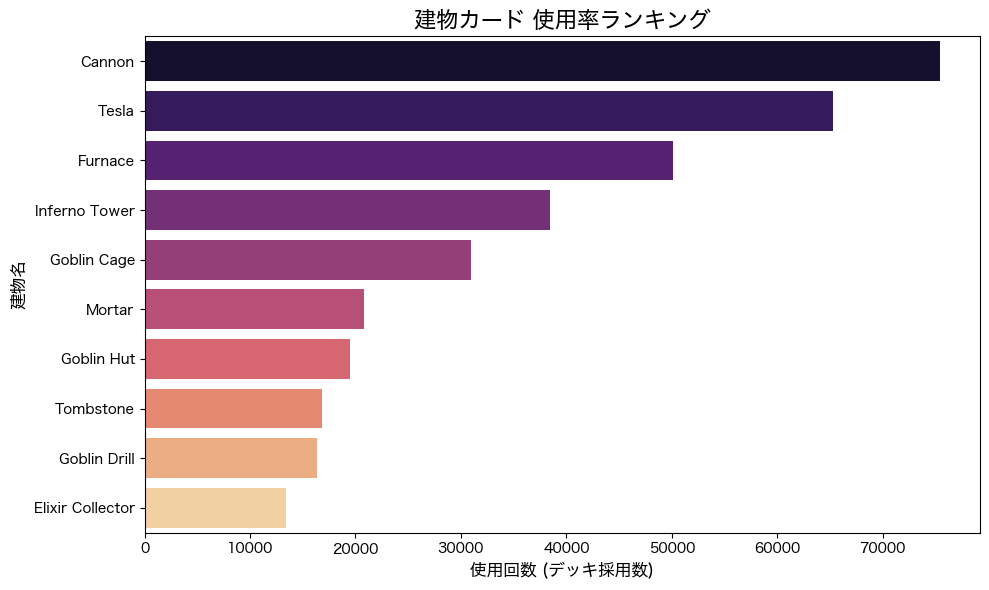

In [14]:
# ==========================================
# 1. デッキから「建物（IDが27000000番台）」だけを抽出
# ==========================================
building_decks_names = []
for deck_ids in decks: # decks は [26000021, 28000011, ...] のような生IDのリスト
    building_deck = []
    for card_id in deck_ids:
        # IDが '27' から始まるものを建物として判定
        if str(card_id).startswith('27'): 
            building_deck.append(id_to_name.get(card_id, f"Unknown({card_id})"))
    building_decks_names.append(building_deck)

# ==========================================
# 2. 建物の使用率ランキング
# ==========================================
all_buildings = [building for deck in building_decks_names for building in deck]
building_counts = Counter(all_buildings)

# 建物は全体の枚数が少ないので、トップ10
top_buildings = building_counts.most_common(10) 
top_building_names = [x[0] for x in top_buildings]
top_building_counts = [x[1] for x in top_buildings]

plt.figure(figsize=(10, 6))
# 建物っぽさを出すために色を 'magma' (紫〜オレンジ) に変更
sns.barplot(x=top_building_counts, y=top_building_names, hue=top_building_names, palette='magma', legend=False)
plt.title('建物カード 使用率ランキング', fontsize=16)
plt.xlabel('使用回数 (デッキ採用数)', fontsize=12)
plt.ylabel('建物名', fontsize=12)
plt.tight_layout()
plt.show()


### デッキ分類のための主軸カード調査
- クラロワのデッキには攻めの主軸となるメインカード（ホグライダー、ゴーレム...）が存在する。それらのカードを軸としてデッキを分類するために、何のカードをメインとしてピックすれば全デッキを網羅できるのか探す。

### One-Hotエンコーディングによるデッキ分類の可視化
- デッキを全カードベクトルの中で採用されているのところだけ1にしてエンコード

全 619647 件中、ランダムに抽出した 3000 件を処理します。
📊 --- 主軸カードの網羅率レポート ---
全データ数: 3000 デッキ
単一主軸デッキ: 1715 (57.2%)
複数主軸デッキ: 1127 (37.6%)
主軸なしデッキ: 158 (5.3%)
分類成功率（網羅率）: 94.7%
------------------------------------

デッキをベクトル化し、t-SNEを実行中


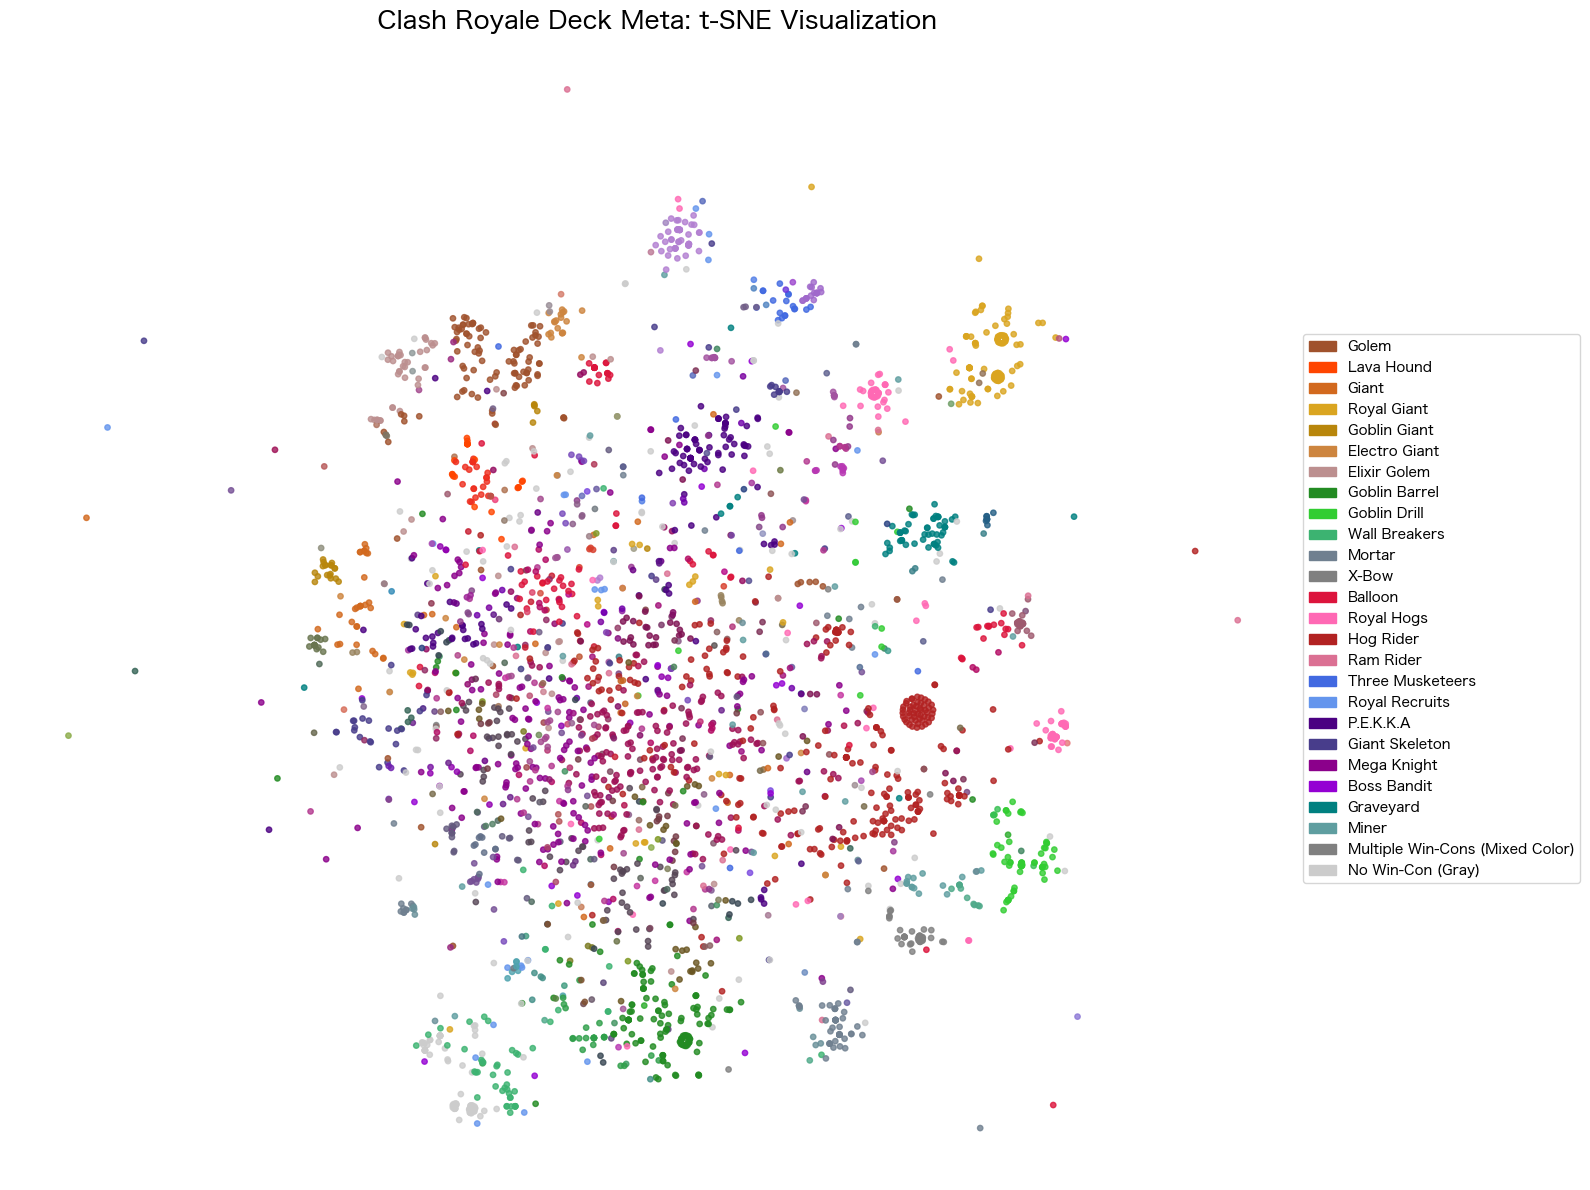

In [33]:
# ==========================================
# 1. メインカードリストの定義
# ==========================================
target_main_cards = [
    #タンク系
    "Golem",               # ゴーレム
    "Lava Hound",          # ラヴァハウンド
    "Giant",               # ジャイアント
    "Royal Giant",         # ロイヤルジャイアント
    "Goblin Giant",        # ゴブジャイアント
    "Electro Giant",       # エレクトロジャイアント
    "Elixir Golem",        # エリクサーゴーレム

    # 枯渇系
    "Goblin Barrel",       # ゴブリンバレル
    "Goblin Drill",        # ゴブリンドリル
    "Wall Breakers",       # ウォールブレイカー

    #建物系
    "Mortar",              # 迫撃砲
    "X-Bow",               # 巨大クロスボウ

    #タワー突撃系
    "Balloon",             # エアバルーン
    "Royal Hogs",          # ロイヤルホグ
    "Hog Rider",           # ホグライダー
    "Ram Rider",           # ラムライダー

    #両サイド系
    "Three Musketeers",    # 三銃士
    "Royal Recruits",      # 見習い親衛隊

    #神器系
    "P.E.K.K.A",           # ペッカ
    "Giant Skeleton",      # 巨大スケルトン
    "Mega Knight",         # メガナイト
    "Boss Bandit",         # ボスアサシン

    #その他
    "Graveyard",           # スケルトンラッシュ
    "Miner"                # ディガー
   
]

# 全デッキに登場したユニークなカード一覧
all_unique_cards = list(set([card for deck in decks_names for card in deck]))

n_samples = 3000 # 描画するデッキ数を指定
random.seed(42)

if len(decks_names) > n_samples:
    sampled_decks_names = random.sample(decks_names, n_samples)
else:
    sampled_decks_names = decks_names

print(f"全 {len(decks_names)} 件中、ランダムに抽出した {len(sampled_decks_names)} 件を処理します。")

# ==========================================
# 2. 網羅率（カバレッジ）の計算
# ==========================================
deck_win_conditions = []
for deck in sampled_decks_names:
    win_cons = [card for card in deck if card in target_main_cards]
    deck_win_conditions.append(win_cons)

zero_main = sum(1 for w in deck_win_conditions if len(w) == 0)
one_main = sum(1 for w in deck_win_conditions if len(w) == 1)
multi_main = sum(1 for w in deck_win_conditions if len(w) > 1)
total_decks = len(sampled_decks_names)

print("📊 --- 主軸カードの網羅率レポート ---")
print(f"全データ数: {total_decks} デッキ")
print(f"単一主軸デッキ: {one_main} ({one_main/total_decks*100:.1f}%)")
print(f"複数主軸デッキ: {multi_main} ({multi_main/total_decks*100:.1f}%)")
print(f"主軸なしデッキ: {zero_main} ({zero_main/total_decks*100:.1f}%)")
print(f"分類成功率（網羅率）: {(one_main + multi_main)/total_decks*100:.1f}%")
print("------------------------------------\n")

# ==========================================
# 3. デッキのベクトル化 (One-Hot Encoding)
# ==========================================
print("デッキをベクトル化し、t-SNEを実行中")
card_to_idx = {card: i for i, card in enumerate(all_unique_cards)}
X = np.zeros((total_decks, len(all_unique_cards)))

for i, deck in enumerate(sampled_decks_names):
    for card in deck:
        X[i, card_to_idx[card]] = 1

# t-SNEによる2次元圧縮
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_2d = tsne.fit_transform(X)

# ==========================================
# 4. メインカード固有色を使ったカラーマッピング 
# ==========================================
# 自分でカードごとのイメージカラーを指定する（英語の色名や #FF0000 などのカラーコードが使えます）
base_colors = {
    # タンク系 (ブラウン・オレンジ・ゴールド系の重量感ある暖色)
    "Golem": to_rgb("sienna"),
    "Lava Hound": to_rgb("orangered"),
    "Giant": to_rgb("chocolate"),
    "Royal Giant": to_rgb("goldenrod"),
    "Goblin Giant": to_rgb("darkgoldenrod"),
    "Electro Giant": to_rgb("peru"),
    "Elixir Golem": to_rgb("rosybrown"),

    # 枯渇系 (ゴブリンを連想させるグリーン系)
    "Goblin Barrel": to_rgb("forestgreen"),
    "Goblin Drill": to_rgb("limegreen"),
    "Wall Breakers": to_rgb("mediumseagreen"),

    # 建物系 (無機物を連想させるグレー・シルバー系)
    "Mortar": to_rgb("slategray"),
    "X-Bow": to_rgb("gray"),

    # タワー突撃系 (ホグライダーや突進系のレッド・ピンク系)
    "Balloon": to_rgb("crimson"),
    "Royal Hogs": to_rgb("hotpink"),
    "Hog Rider": to_rgb("firebrick"),
    "Ram Rider": to_rgb("palevioletred"),

    # 両サイド系 (王室やマスケット銃士のブルー系)
    "Three Musketeers": to_rgb("royalblue"),
    "Royal Recruits": to_rgb("cornflowerblue"),

    # 神器系 (ダークで圧迫感のあるパープル・ネイビー系)
    "P.E.K.K.A": to_rgb("indigo"),
    "Giant Skeleton": to_rgb("darkslateblue"),
    "Mega Knight": to_rgb("darkmagenta"),
    "Boss Bandit": to_rgb("darkviolet"),

    # その他 (独立したシアン・青緑系)
    "Graveyard": to_rgb("teal"),
    "Miner": to_rgb("cadetblue")
}

point_colors = []
for win_cons in deck_win_conditions:
    if len(win_cons) == 0:
        point_colors.append((0.8, 0.8, 0.8, 0.3)) 
    elif len(win_cons) == 1:
        point_colors.append(base_colors[win_cons[0]]) 
    else:
        avg_color = np.mean([base_colors[wc] for wc in win_cons], axis=0)
        point_colors.append(tuple(avg_color)) # NDArrayをタプルに戻して追加

# ==========================================
# 5. 可視化 (Scatter Plot)
# ==========================================
plt.figure(figsize=(16, 12))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=point_colors, s=15, alpha=0.8)

# 凡例（Legend）の作成
legend_patches = []
for card in target_main_cards:
    if card in all_unique_cards: 
        patch = mpatches.Patch(color=base_colors[card], label=card)
        legend_patches.append(patch)

# 複数主軸と主軸なしの凡例も追加
legend_patches.append(mpatches.Patch(color=(0.5, 0.5, 0.5), label='Multiple Win-Cons (Mixed Color)'))
legend_patches.append(mpatches.Patch(color=(0.8, 0.8, 0.8), label='No Win-Con (Gray)'))

plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.title(' Clash Royale Deck Meta: t-SNE Visualization', fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.show()

### 事前学習モデルのエンコードによるデッキ分類T-SNE

学習済みの重みを正常にインポートしました。
全 619647 件中、ランダムに抽出した 3000 件を処理します。
モデルの重みを使用して特徴量ベクトルを抽出中...
t-SNEによる次元削減を実行中...


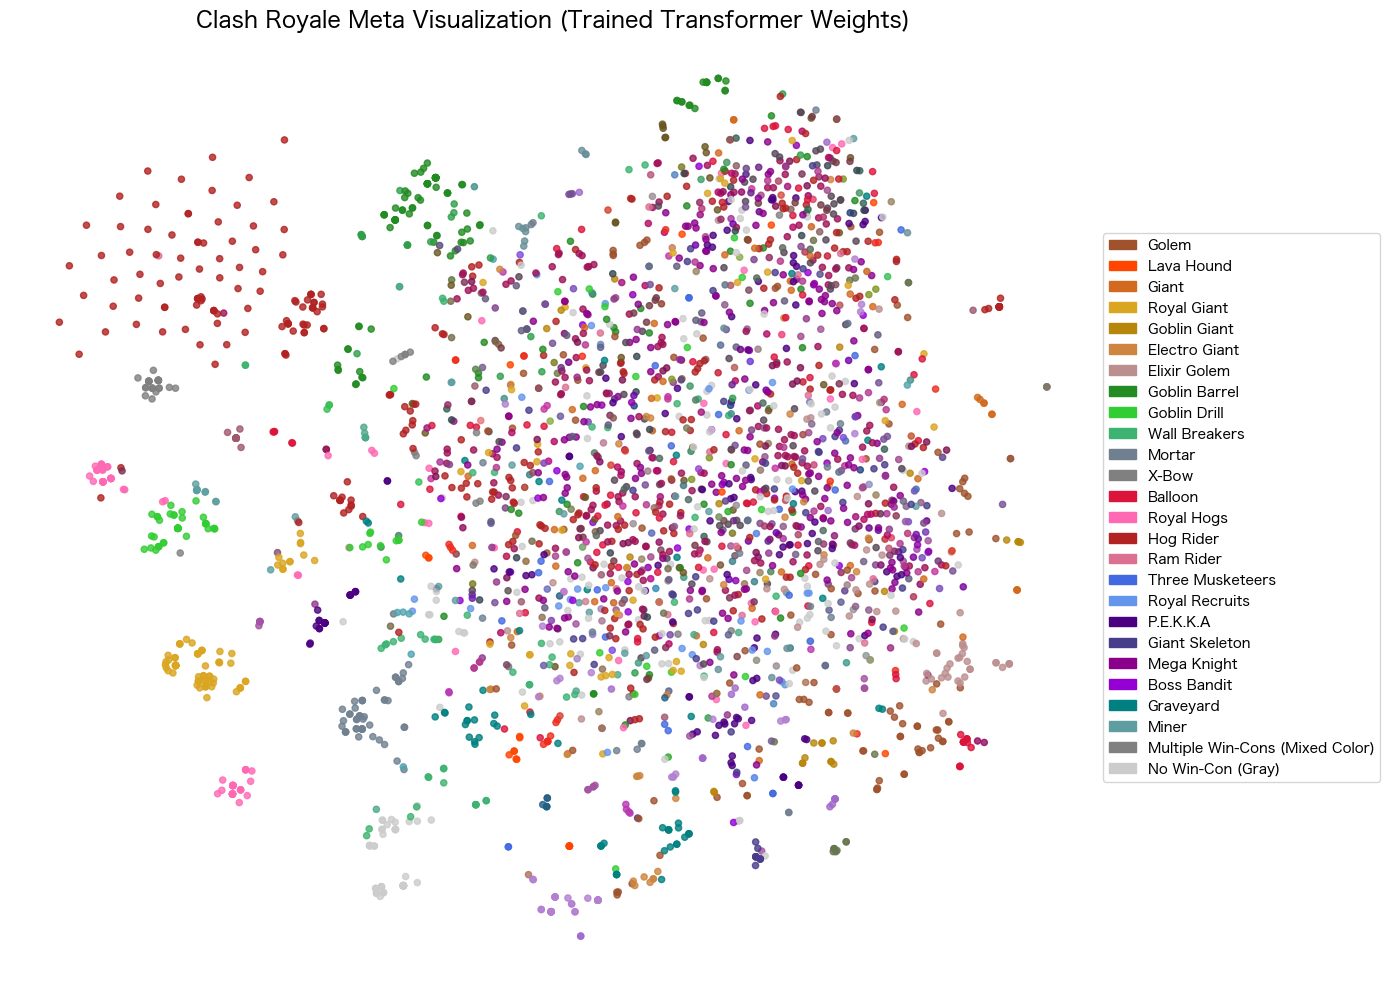

In [34]:
target_dir = '../src'
if target_dir not in sys.path:
    sys.path.append(target_dir)
from pre_train_model import DeckTransformer

# ==========================================
# 0. 辞書の準備とモデルのロード（修正箇所）
# ==========================================
# 辞書の復元
name_to_id = {name: id_val for id_val, name in id_to_name.items()}
raw_ids = list(id_to_name.keys())
id_to_idx = {raw_id: i for i, raw_id in enumerate(raw_ids)}
unk_idx = len(raw_ids)
vocab_size = len(raw_ids) + 1

# ★ モデルのインスタンス化と重みのロード
# d_modelやnheadなどのパラメータは、学習時と同じ数値を指定してください
model = DeckTransformer(vocab_size=vocab_size, d_model=128, nhead=4, num_layers=4)

# 学習済みの重みファイル（.pth）のパスを指定して読み込む
# ※パスはご自身の環境に合わせて変更してください
model_path = '../models/deck_encoder.pth' 
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval() # 評価モードに切り替え

print("学習済みの重みを正常にインポートしました。")

# ==========================================
# 1. データのサブセット化
# ==========================================
n_samples = 3000 
random.seed(42)

if len(decks_names) > n_samples:
    sampled_decks_names = random.sample(decks_names, n_samples)
else:
    sampled_decks_names = decks_names

print(f"全 {len(decks_names)} 件中、ランダムに抽出した {len(sampled_decks_names)} 件を処理します。")

# ==========================================
# 2. サブセットに対する色の割り当て計算
# ==========================================
deck_win_conditions_subset = []
for deck in sampled_decks_names:
    win_cons = [card for card in deck if card in target_main_cards]
    deck_win_conditions_subset.append(win_cons)

point_colors_subset = []
for win_cons in deck_win_conditions_subset:
    if len(win_cons) == 0:
        point_colors_subset.append((0.8, 0.8, 0.8, 0.3)) 
    elif len(win_cons) == 1:
        point_colors_subset.append(base_colors[win_cons[0]]) 
    else:
        avg_color = np.mean([base_colors[wc] for wc in win_cons], axis=0)
        point_colors_subset.append(tuple(avg_color))

# ==========================================
# 3. Transformerモデルによる重みベクトルの抽出
# ==========================================
deck_tensors = []
for deck in sampled_decks_names:
    idx_list = [id_to_idx.get(name_to_id.get(name), unk_idx) for name in deck]
    if len(idx_list) == 8:
        deck_tensors.append(idx_list)

X_tensor = torch.tensor(deck_tensors, dtype=torch.long)

print("モデルの重みを使用して特徴量ベクトルを抽出中...")
with torch.no_grad():
    embeddings = model.embedding(X_tensor) * math.sqrt(model.d_model)
    transformer_out = model.transformer_encoder(embeddings)
    X_encoded = transformer_out.mean(dim=1)

X_features = X_encoded.cpu().numpy()

# ==========================================
# 4. t-SNEによる次元削減と可視化
# ==========================================
print("t-SNEによる次元削減を実行中...")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_2d_transformer = tsne.fit_transform(X_features)

plt.figure(figsize=(14, 10))
plt.scatter(X_2d_transformer[:, 0], X_2d_transformer[:, 1], 
            c=point_colors_subset[:len(X_2d_transformer)], s=20, alpha=0.8)

plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.title('Clash Royale Meta Visualization (Trained Transformer Weights)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()